In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("C:\\Users\\Mainuddin\\Downloads\\archive (1)\\sales_data_sample.csv",encoding='latin-1')

In [3]:
df.sample(6)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
1157,10310,49,100.00,12,6266.12,10/16/2004 0:00,Shipped,4,10,2004,...,Mehrheimerstr. 369,NaN,Koln,NaN,50739,Germany,EMEA,Pfalzheim,Henriette,Medium
342,10108,39,89.38,7,3485.82,3/3/2003 0:00,Shipped,1,3,2003,...,15 McCallum Street - NatWest Center #13-03,NaN,Makati City,NaN,1227 MM,Philippines,Japan,Cruz,Arnold,Medium
1039,10266,29,100.00,7,4812.55,7/6/2004 0:00,Shipped,3,7,2004,...,Strada Provinciale 124,NaN,Reggio Emilia,NaN,42100,Italy,EMEA,Moroni,Maurizio,Medium
2030,10182,23,42.26,8,971.98,11/12/2003 0:00,Shipped,4,11,2003,...,5677 Strong St.,NaN,San Rafael,CA,97562,USA,NaN,Nelson,Valarie,Small
2188,10318,47,100.00,7,5305.36,11/2/2004 0:00,Shipped,4,11,2004,...,7586 Pompton St.,NaN,Allentown,PA,70267,USA,NaN,Yu,Kyung,Medium
855,10421,35,100.00,1,5433.75,5/29/2005 0:00,In Process,2,5,2005,...,5677 Strong St.,NaN,San Rafael,CA,97562,USA,NaN,Nelson,Valarie,Medium


In [4]:
df.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [6]:
df=df.drop(columns=['ADDRESSLINE2'])

In [7]:
df.columns

Index(['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER',
       'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID',
       'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE',
       'ADDRESSLINE1', 'CITY', 'STATE', 'POSTALCODE', 'COUNTRY', 'TERRITORY',
       'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE'],
      dtype='object')

In [8]:
# Nulls in STATE
df['STATE'] = df['STATE'].fillna('Not Aplicable')


In [9]:
df['POSTALCODE']= df['POSTALCODE'].fillna('00000')

In [10]:
# Nulls in TERRITORY, assigning "NA" for USA and Canada
df.loc[df["COUNTRY"].isin(["USA", "Canada"]), "TERRITORY"] = "NA"
# Verify the values
print(df['TERRITORY'].unique())

['NA' 'EMEA' 'APAC' 'Japan']


In [11]:
print(df.isnull().sum())

ORDERNUMBER         0
QUANTITYORDERED     0
PRICEEACH           0
ORDERLINENUMBER     0
SALES               0
ORDERDATE           0
STATUS              0
QTR_ID              0
MONTH_ID            0
YEAR_ID             0
PRODUCTLINE         0
MSRP                0
PRODUCTCODE         0
CUSTOMERNAME        0
PHONE               0
ADDRESSLINE1        0
CITY                0
STATE               0
POSTALCODE          0
COUNTRY             0
TERRITORY           0
CONTACTLASTNAME     0
CONTACTFIRSTNAME    0
DEALSIZE            0
dtype: int64


In [12]:
print(df.duplicated().sum())

0


In [13]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  CITY              2823 non-null   object 


In [14]:
# Convert the column ORDERDATE to datetime type
df['ORDERDATE']= pd.to_datetime(df['ORDERDATE'])
# Verify the data type of the ORDERDATE column
print(df.dtypes['ORDERDATE'])

datetime64[ns]


In [15]:
df.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2004-05-11 00:16:49.989373056,2.717676,7.092455,2003.81509,100.715551
min,10100.000000,6.000000,26.880000,1.000000,482.130000,2003-01-06 00:00:00,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2003-11-06 12:00:00,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,2004-06-15 00:00:00,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,2004-11-17 12:00:00,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,2005-05-31 00:00:00,4.000000,12.000000,2005.00000,214.000000
std,92.085478,9.741443,20.174277,4.225841,1841.865106,NaN,1.203878,3.656633,0.69967,40.187912


In [16]:
print(f"Mean: {df['SALES'].mean():.2f}")
print(f"Median: {df['SALES'].median():.2f}")
print(f"Mode: {df['SALES'].mode()[0]:.2f}")
print(f"Standard deviation: {df['SALES'].std():.2f}")
print(f"Variance: {df['SALES'].var():.2f}")

Mean: 3553.89
Median: 3184.80
Mode: 3003.00
Standard deviation: 1841.87
Variance: 3392467.07


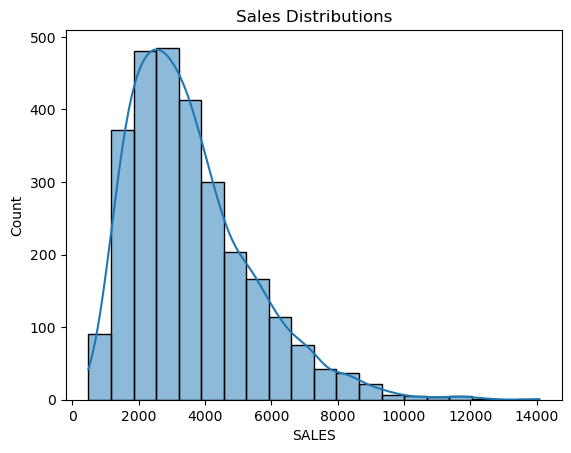

In [17]:
sns.histplot(df['SALES'], bins=20, kde=True); plt.title('Sales Distributions'); plt.show()

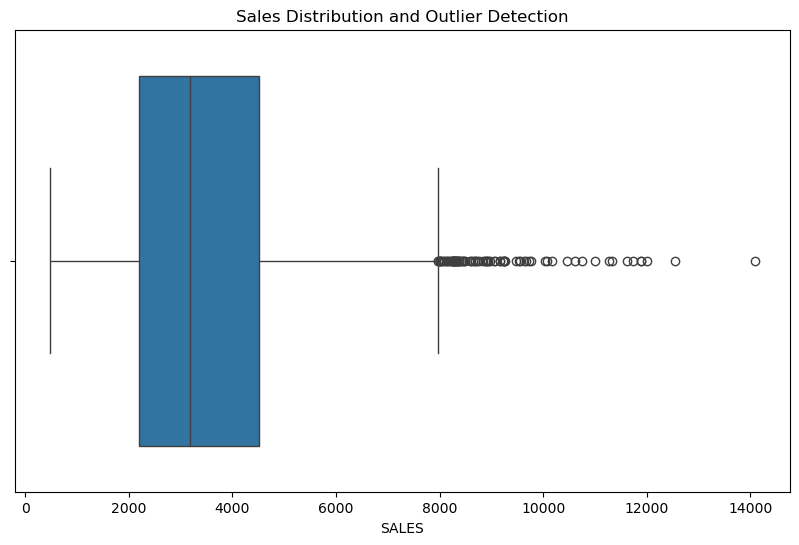

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['SALES'])
plt.title('Sales Distribution and Outlier Detection')
plt.show()

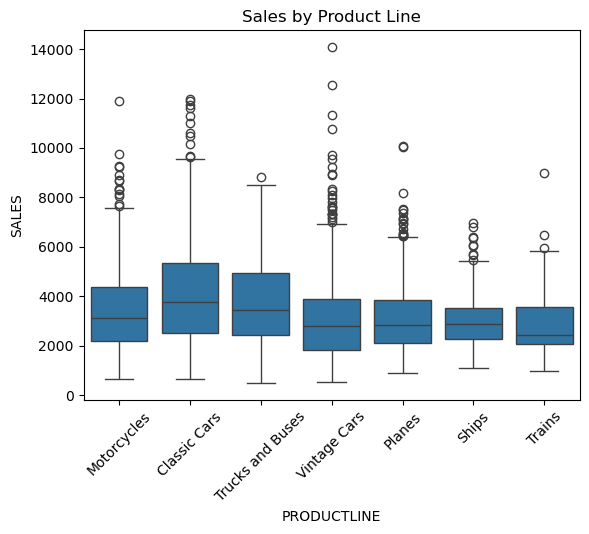

In [20]:
sns.boxplot(x='PRODUCTLINE', y='SALES', data=df); plt.title('Sales by Product Line'); plt.xticks(rotation=45)
plt.show()

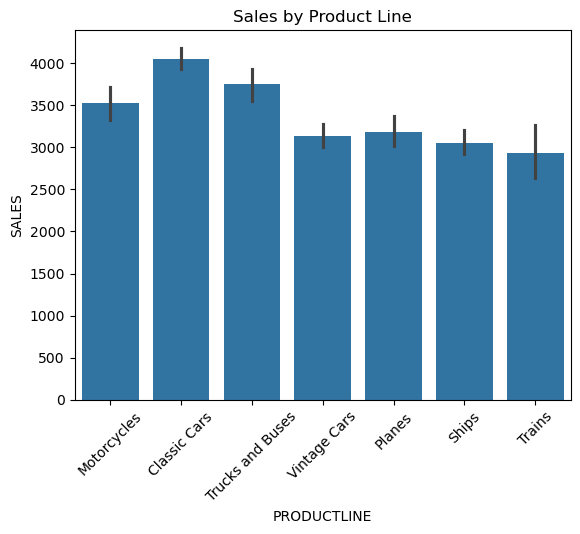

In [21]:
sns.barplot(x='PRODUCTLINE', y='SALES', data=df); plt.title('Sales by Product Line'); plt.xticks(rotation=45)
plt.show()


In [23]:
top10 = (
    df.groupby("COUNTRY")["SALES"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .index
)
top10 = list(top10)

# Filtering data just for top 10 paises
df_top10 = df[df["COUNTRY"].isin(top10)].copy()
country_product_sales = (
    df_top10.groupby(["COUNTRY", "PRODUCTLINE"])["SALES"]
            .sum()
            .reset_index(name="sales_product")
)

# Identification of the product with highest sales in each country
top_product_in_top10 = (
    country_product_sales.sort_values(["COUNTRY", "sales_product"], ascending=[True, False])
                         .groupby("COUNTRY", as_index=False)
                         .head(1)
)
top_product_in_top10

,COUNTRY,PRODUCTLINE,sales_product
0,Australia,Classic Cars,193085.54
7,Denmark,Classic Cars,157182.48
13,Finland,Classic Cars,153552.24
20,France,Classic Cars,388951.20
27,Italy,Classic Cars,128576.65
34,Norway,Classic Cars,134787.37
40,Singapore,Classic Cars,132890.44
46,Spain,Classic Cars,476165.15
53,UK,Classic Cars,159377.70
60,USA,Classic Cars,1344638.22


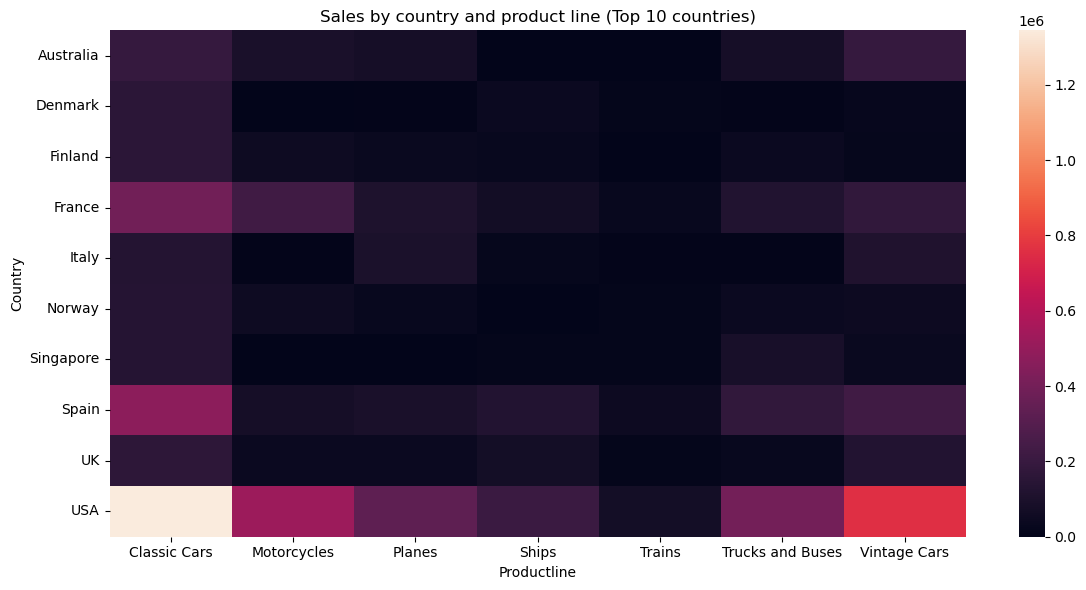

In [24]:
pivot = country_product_sales.pivot(index="COUNTRY", columns="PRODUCTLINE", values="sales_product").fillna(0)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=False)
plt.title("Sales by country and product line (Top 10 countries)")
plt.xlabel("Productline")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [25]:
num_cols = ["SALES", "PRICEEACH", "QUANTITYORDERED", "MSRP"]
corr_matrix = df[num_cols].corr(method="pearson")
corr_matrix.round(2)

,SALES,PRICEEACH,QUANTITYORDERED,MSRP
SALES,1.00,0.66,0.55,0.64
PRICEEACH,0.66,1.00,0.01,0.67
QUANTITYORDERED,0.55,0.01,1.00,0.02
MSRP,0.64,0.67,0.02,1.00


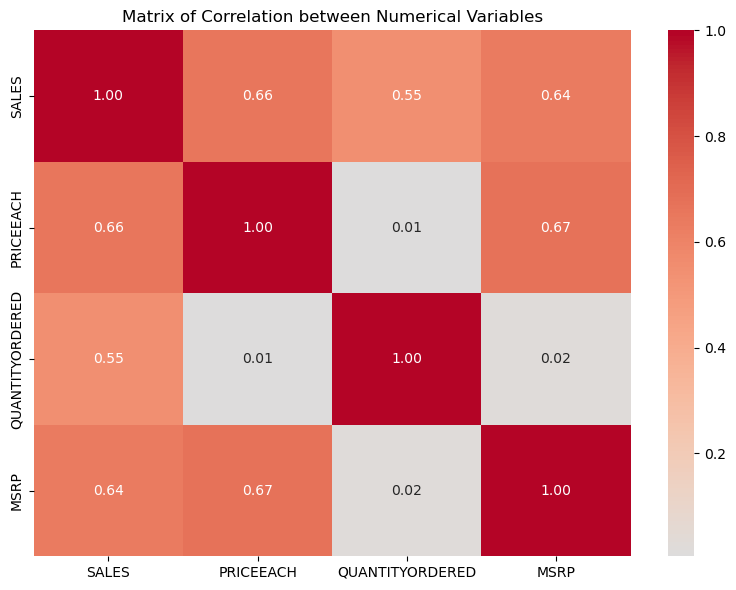

In [26]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Matrix of Correlation between Numerical Variables")
plt.tight_layout()
plt.show()